In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!apt-get install -y aria2
!pip install requests beautifulsoup4

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libaria2-0 libc-ares2
The following NEW packages will be installed:
  aria2 libaria2-0 libc-ares2
0 upgraded, 3 newly installed, 0 to remove and 51 not upgraded.
Need to get 1,513 kB of archives.
After this operation, 5,441 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libc-ares2 amd64 1.18.1-1ubuntu0.22.04.3 [45.1 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libaria2-0 amd64 1.36.0-1 [1,086 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 aria2 amd64 1.36.0-1 [381 kB]
Fetched 1,513 kB in 0s (23.9 MB/s)
Selecting previously unselected package libc-ares2:amd64.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../libc-ares2_1.18.1-1ubuntu0.22.04.3_amd64.deb ...
Unpacking libc-ares2:amd64 (1.18.1-1ubunt

In [ ]:
import requests
from bs4 import BeautifulSoup

amc_urls = []
for i in range(1, 145):
    subj = str(i).zfill(2)
    url = f"http://mocap.cs.cmu.edu/subjects/{subj}/"
    r = requests.get(url)
    soup = BeautifulSoup(r.text, "html.parser")
    for link in soup.find_all("a"):
        href = link.get("href", "")
        if href.endswith(".amc"):
            amc_urls.append(f"http://mocap.cs.cmu.edu/subjects/{subj}/{href}")

print(f"Total .amc files found: {len(amc_urls)}")

# Download all in parallel
with open("amc_urls.txt", "w") as f:
    f.write("\n".join(amc_urls))

!aria2c -i amc_urls.txt -j 16 -x 4 --dir="./amc_files"

Streaming output truncated to the last 5000 lines.

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_16.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_17.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_18.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_19.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_20.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_22.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_21.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/32_11.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_23.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_26.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_24.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_25.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/31_14.amc

05/20 03:55:09 [NOTICE] Download complete: ./amc_files/35_28.amc

05/20 03:55:09 [NOTICE] 

In [15]:
#parse the amc file
def parse_mocap(filepath: str) -> torch.Tensor:
    frames = []
    current = []

    for line in open(filepath):
        line = line.strip()
        if not line or line.startswith(":") or line.startswith("#"):
            continue
        if line.isdigit():
            if current:
                frames.append(current)
            current = []
        else:
            parts = line.split()
            current.extend(float(v) for v in parts[1:])

    if current:
        frames.append(current)

    max_len = max(len(f) for f in frames)
    frames = [f + [0.0]*(max_len-len(f)) for f in frames]

    return torch.tensor(frames) #returns a tensor of shape (n_frames, action_dim)


In [ ]:
from multiprocessing import Pool
from pathlib import Path
import torch

amc_files = sorted(Path("./amc_files").glob("*.amc"))

def safe_parse(filepath):
    try:
        tensor = parse_mocap(str(filepath))
        subject = filepath.name.split("_")[0]  # "01" from "01_02.amc"
        return (subject, tensor)
    except Exception as e:
        print(f"Skipped {filepath.name}: {e}")
        return None

with Pool() as pool:
    results = pool.map(safe_parse, amc_files)
results = [r for r in results if r is not None]

# Group clips by subject
from collections import defaultdict
subject_clips = defaultdict(list)
for subject, tensor in results:
    subject_clips[subject].append(tensor)

subjects = list(subject_clips.keys())

# 80/10/10 on subjects
n = len(subjects)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

train_subjects = subjects[:n_train]
val_subjects   = subjects[n_train:n_train + n_val]
test_subjects  = subjects[n_train + n_val:]

train = torch.cat([t for s in train_subjects for t in subject_clips[s]], dim=0)
val   = torch.cat([t for s in val_subjects   for t in subject_clips[s]], dim=0)
test  = torch.cat([t for s in test_subjects  for t in subject_clips[s]], dim=0)

print(f"Subjects — Train: {len(train_subjects)} | Val: {len(val_subjects)} | Test: {len(test_subjects)}")
print(f"Shapes   — Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")

torch.save(train, "/content/drive/MyDrive/mocap_train_tensor_v2.pt")
torch.save(val,   "/content/drive/MyDrive/mocap_val_tensor_v2.pt")
torch.save(test,  "/content/drive/MyDrive/mocap_test_tensor_v2.pt")

Subjects — Train: 88 | Val: 11 | Test: 12
Shapes   — Train: torch.Size([3288377, 62]) | Val: torch.Size([481390, 62]) | Test: torch.Size([436039, 62])


In [ ]:
print(train_subjects)
print(val_subjects)
print(test_subjects)

['01', '02', '03', '05', '06', '07', '08', '09', '102', '103', '104', '105', '106', '107', '108', '10', '111', '113', '114', '115', '118', '11', '120', '122', '123', '124', '125', '126', '127', '128', '12', '131', '132', '133', '134', '135', '136', '137', '138', '139', '13', '140', '141', '142', '143', '144', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '45', '46', '47', '49', '54', '55', '56', '60', '61', '62', '63', '64']
['69', '70', '73', '74', '75', '76', '77', '78', '79', '80', '81']
['82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '93', '94']


In [3]:
#get the datasets
#from google.colab import drive
#drive.mount('/content/drive')

train_set = torch.load("/content/drive/MyDrive/mocap_train_tensor_v2.pt")
val_set   = torch.load("/content/drive/MyDrive/mocap_val_tensor_v2.pt")
test_set  = torch.load("/content/drive/MyDrive/mocap_test_tensor_v2.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_set = train_set.to(device)
val_set   = val_set.to(device)
test_set  = test_set.to(device)

print(train_set.shape, val_set.shape, test_set.shape)

torch.Size([3288377, 62]) torch.Size([481390, 62]) torch.Size([436039, 62])


In [4]:
#find mean and std of the training set
mean = train_set.mean(dim=0)
std  = train_set.std(dim=0) + 1e-8

In [5]:
#normalise the dataset
train_set = (train_set-mean)/std
val_set = (val_set-mean)/std
test_set = (test_set-mean)/std

In [6]:
#hyperparameters
action_dim  = 62
d_model     = 256
num_heads   = 8
num_layers  = 10
max_seq     = 64 #sliding window
_batch_size  = 1024
_lr          = 1e-4

#encoder
class ActionEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Linear(action_dim, d_model)

    def forward(self, x):
        # x shape: (batch, seq, action_dim)
        return self.proj(x)
        # output shape: (batch, seq, d_model)


#transformer block
class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn  = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model)
        )

    def forward(self, x):
        normed = self.norm1(x)
        T = x.shape[1]
        mask = torch.nn.Transformer.generate_square_subsequent_mask(T).to(device)
        x = x + self.attn(normed, normed, normed, attn_mask=mask, is_causal=True)[0]
        x = x + self.ffn(self.norm2(x))

        return x

#decoder
class ActionDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Linear(d_model, action_dim)

    def forward(self, x):
        # x shape: (batch, seq, d_model)
        return self.proj(x)
        # output shape: (batch, seq, action_dim)


#full unimodal model
class Mars(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = ActionEncoder()
        self.pos_emb = nn.Embedding(max_seq, d_model)
        self.blocks  = nn.ModuleList([TransformerBlock() for _ in range(num_layers)])
        self.decoder = ActionDecoder()

    def forward(self, x):
        # x shape: (batch, seq, action_dim)
        x = self.encoder(x)
        positions = torch.arange(x.shape[1], device=x.device)
        x = x + self.pos_emb(positions)
        for block in self.blocks:
            x = block(x)
        # decode last token, that's the next frame prediction
        x = self.decoder(x[:, -1, :])
        # output shape: (batch, action_dim)
        return x

model = Mars().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=_lr)
loss_fn = nn.MSELoss()

In [9]:
#lets train

#train by scheduled sampling
def train_step_scheduled_sampling(data, batch_size=_batch_size, teacher_forcing_ratio=0.5):
    max_start = data.shape[0] - max_seq - 1
    starts = torch.randint(0, max_start, (batch_size,))
    input  = torch.stack([data[s : s + max_seq] for s in starts])
    target = torch.stack([data[s + max_seq] for s in starts])

    # sometimes replace last few frames with model's own predictions
    if torch.rand(1).item() > teacher_forcing_ratio:
        with torch.no_grad():
            pred_prev = model(input[:, :-1, :] if input.shape[1] > 1 else input)
            input[:, -1, :] = pred_prev

    pred = model(input)
    loss = loss_fn(pred, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

def train_scheduled_sampling(data, val_data, n_steps=1000):
    losses, val_losses = [], []
    for step in range(n_steps):
        ratio = max(0.5, 0.9 - (step / n_steps) * 0.4)  # decay 0.9 → 0.5
        loss = train_step_scheduled_sampling(data, teacher_forcing_ratio=ratio)
        losses.append(loss)
        if step % 50 == 0:
            val_loss = test(val_set)
            val_losses.append((step, val_loss))
            print(f"step {step:6d}  train {loss:.6f}  val {val_loss:.6f}  tf_ratio {ratio:.2f}")
    return losses, val_losses

#teacher forced training
def train_step_teacher_forced(data, batch_size=_batch_size):
    max_start = data.shape[0] - max_seq - 1
    starts = torch.randint(0, max_start, (batch_size,))
    input  = torch.stack([data[s : s + max_seq] for s in starts])
    target = torch.stack([data[s + max_seq] for s in starts])
    pred   = model(input)
    loss   = loss_fn(pred, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

def train_teacher_forced(data, val_data, n_steps=100):
    losses, val_losses = [], []
    for step in range(n_steps):
        loss = train_step_teacher_forced(data)
        losses.append(loss)
        if step % 50 == 0:
            val_loss = test(val_set)
            val_losses.append((step, val_loss))
            print(f"step {step:6d}  train {loss:.6f}  val {val_loss:.6f}")
    return losses, val_losses

losses, val_losses = train_scheduled_sampling(train_set, val_set, n_steps=1000)

step      0  train 1.352520  val 1.004487  tf_ratio 0.90
step     50  train 0.209563  val 0.255971  tf_ratio 0.88
step    100  train 0.092572  val 0.071508  tf_ratio 0.86
step    150  train 0.177628  val 0.060354  tf_ratio 0.84
step    200  train 0.035598  val 0.023823  tf_ratio 0.82
step    250  train 0.058404  val 0.105272  tf_ratio 0.80
step    300  train 0.029242  val 0.057379  tf_ratio 0.78
step    350  train 0.052434  val 0.024794  tf_ratio 0.76
step    400  train 0.016338  val 0.015418  tf_ratio 0.74
step    450  train 0.019524  val 0.015164  tf_ratio 0.72
step    500  train 0.023425  val 0.020707  tf_ratio 0.70
step    550  train 0.017617  val 0.011577  tf_ratio 0.68
step    600  train 0.044575  val 0.039965  tf_ratio 0.66
step    650  train 0.030633  val 0.023898  tf_ratio 0.64
step    700  train 0.012219  val 0.008242  tf_ratio 0.62
step    750  train 0.008159  val 0.012462  tf_ratio 0.60
step    800  train 0.020311  val 0.018328  tf_ratio 0.58
step    850  train 0.027260  va

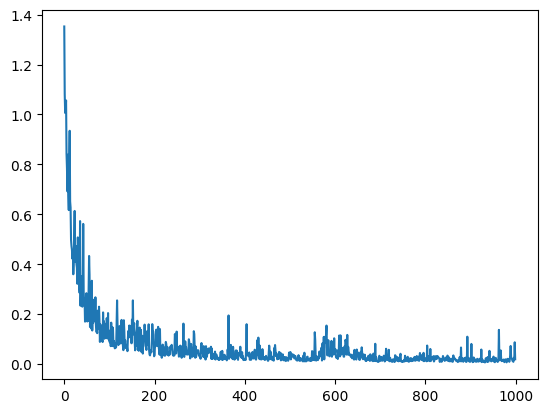

In [10]:
plt.plot(losses)

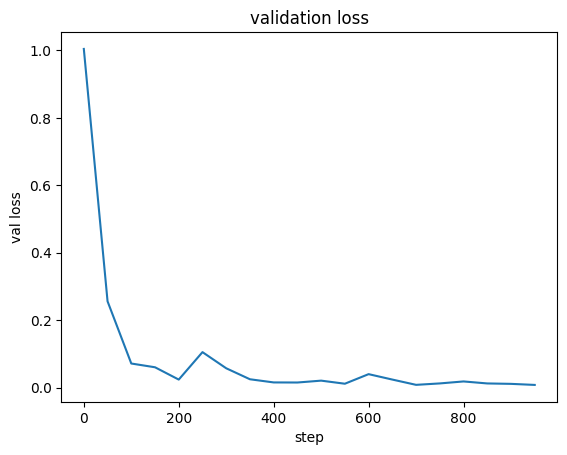

In [11]:
steps = [x[0] for x in val_losses]
vals  = [x[1] for x in val_losses]
plt.plot(steps, vals)
plt.xlabel('step')
plt.ylabel('val loss')
plt.title('validation loss')
plt.show()

In [8]:
#test
def test(seq, n_windows=500):
    model.eval()
    losses = []
    max_start = seq.shape[0] - max_seq - 1
    with torch.no_grad():
        for _ in range(n_windows):
            s = torch.randint(0, max_start, (1,)).item()
            input  = seq[s : s + max_seq].unsqueeze(0)
            target = seq[s + max_seq].unsqueeze(0)
            pred   = model(input)
            loss   = loss_fn(pred, target)
            losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)

In [12]:
print(f"test loss: {test(test_set, n_windows=500)}")

test loss: 0.05854121149843559


In [13]:
torch.save(model.state_dict(), '/content/drive/MyDrive/mars_v7.pt')

In [16]:
#training set test
cartwheels        = (parse_mocap("/content/drive/MyDrive/test_datasets/cartwheels.amc ").to(device) - mean) / std
kicking           = (parse_mocap("/content/drive/MyDrive/test_datasets/kicking.amc ").to(device) - mean) / std
punching          = (parse_mocap("/content/drive/MyDrive/test_datasets/punching.amc").to(device) - mean) / std
range_of_motion   = (parse_mocap("/content/drive/MyDrive/test_datasets/range_of_motion.amc").to(device) - mean) / std
run_to_stop       = (parse_mocap("/content/drive/MyDrive/test_datasets/run_to_stop.amc").to(device) - mean) / std
walk_n_pickup     = (parse_mocap("/content/drive/MyDrive/test_datasets/walk_n_pickup.amc ").to(device) - mean) / std
walk_n_stepover   = (parse_mocap("/content/drive/MyDrive/test_datasets/walk_n_stepover.amc ").to(device) - mean) / std
waving            = (parse_mocap("/content/drive/MyDrive/test_datasets/waving.amc").to(device) - mean) / std
chicken_dance     = (parse_mocap("/content/drive/MyDrive/test_datasets/chicken_dance.amc ").to(device) - mean) / std

In [17]:
#ultimate test
backflip                  = (parse_mocap("/content/drive/MyDrive/ultimate_test/backflip.amc").to(device) - mean) / std
bounceshootdribblebasketball = (parse_mocap("/content/drive/MyDrive/ultimate_test/bounceshootdribblebasketball.amc").to(device) - mean) / std
carefulwalklookingaround  = (parse_mocap("/content/drive/MyDrive/ultimate_test/carefulwalklookingaround.amc").to(device) - mean) / std
fancyfootwork             = (parse_mocap("/content/drive/MyDrive/ultimate_test/fancyfootwork.amc").to(device) - mean) / std
hop_forward               = (parse_mocap("/content/drive/MyDrive/ultimate_test/hop_forward.amc").to(device) - mean) / std
indian_dance              = (parse_mocap("/content/drive/MyDrive/ultimate_test/indian_dance.amc").to(device) - mean) / std
sadwalk                   = (parse_mocap("/content/drive/MyDrive/ultimate_test/sadwalk.amc").to(device) - mean) / std

In [18]:
print(f"cartwheels:        {test(cartwheels,        n_windows=500)}")
print(f"chicken_dance:     {test(chicken_dance,     n_windows=500)}")
print(f"kicking:           {test(kicking,           n_windows=500)}")
print(f"punching:          {test(punching,          n_windows=500)}")
print(f"range_of_motion:   {test(range_of_motion,   n_windows=500)}")
print(f"run_to_stop:       {test(run_to_stop,       n_windows=500)}")
print(f"walk_n_pickup:     {test(walk_n_pickup,     n_windows=500)}")
print(f"walk_n_stepover:   {test(walk_n_stepover,   n_windows=500)}")
print(f"waving:            {test(waving,            n_windows=500)}")

cartwheels:        0.07040373776759952
chicken_dance:     0.008877799162641168
kicking:           0.009348960881121457
punching:          0.010973335039801895
range_of_motion:   0.16870638946816324
run_to_stop:       0.007467100229114294
walk_n_pickup:     0.008849097825586795
walk_n_stepover:   0.010112366666086017
waving:            0.009084607180207968


In [19]:
print(f"backflip:                     {test(backflip,                     n_windows=500)}")
print(f"bounceshootdribblebasketball: {test(bounceshootdribblebasketball, n_windows=500)}")
print(f"carefulwalklookingaround:     {test(carefulwalklookingaround,     n_windows=500)}")
print(f"fancyfootwork:                {test(fancyfootwork,                n_windows=500)}")
print(f"hop_forward:                  {test(hop_forward,                  n_windows=500)}")
print(f"indian_dance:                 {test(indian_dance,                 n_windows=500)}")
print(f"sadwalk:                      {test(sadwalk,                      n_windows=500)}")

backflip:                     0.16978910483419896
bounceshootdribblebasketball: 0.008691560407169164
carefulwalklookingaround:     0.007334409459494054
fancyfootwork:                0.07463733350485563
hop_forward:                  0.009066272678785027
indian_dance:                 0.3361078409273177
sadwalk:                      0.007445368574932217


In [23]:
def autoregressive_mse(model, seq, n_seed=64, n_steps=180):
    model.eval()
    n_steps = min(n_steps, len(seq) - n_seed)
    seed = seq[:n_seed].clone()
    ground_truth = seq[n_seed:n_seed + n_steps]
    generated = seed.clone()
    with torch.no_grad():
        for _ in range(n_steps):
            input_seq = generated[-max_seq:].unsqueeze(0)
            pred = model(input_seq).squeeze(0)
            generated = torch.cat([generated, pred.unsqueeze(0)], dim=0)
    predicted = generated[n_seed:n_seed + n_steps]
    mse = torch.mean((predicted - ground_truth) ** 2).item()
    return mse

def autoregressive_plot(model, seq, name="motion", n_seed=64, n_steps=180):
    model.eval()
    n_steps = min(n_steps, len(seq) - n_seed)
    seed = seq[:n_seed].clone()
    generated = seed.clone()
    with torch.no_grad():
        for _ in range(n_steps):
            input_seq = generated[-max_seq:].unsqueeze(0)
            pred = model(input_seq).squeeze(0)
            generated = torch.cat([generated, pred.unsqueeze(0)], dim=0)
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(3, 1, figsize=(12, 8))
    full = seq[:n_seed + n_steps].cpu().numpy()
    gen = generated.cpu().numpy()
    for i, joint in enumerate([0, 10, 20]):
        axes[i].plot(full[:, joint], label='ground truth', color='blue')
        axes[i].plot(range(n_seed, n_seed + n_steps), gen[n_seed:n_seed+n_steps, joint],
                    label='generated', color='red', linestyle='--')
        axes[i].axvline(x=n_seed, color='black', linestyle=':')
        axes[i].set_title(f'{name} - Joint {joint}')
        axes[i].legend()
    plt.tight_layout()
    plt.show()

In [26]:
#test outside the training set
print("Individual test set eval")
print("backflip:              ", autoregressive_mse(model, backflip))
print("bounceshootdribble:    ", autoregressive_mse(model, bounceshootdribblebasketball))
print("carefulwalk:           ", autoregressive_mse(model, carefulwalklookingaround))
print("fancyfootwork:         ", autoregressive_mse(model, fancyfootwork))
print("hop_forward:           ", autoregressive_mse(model, hop_forward))
print("indian_dance:          ", autoregressive_mse(model, indian_dance))
print("sadwalk:               ", autoregressive_mse(model, sadwalk))

#test inside the training set
print("Individual train set eval:")
print("cartwheels:            ", autoregressive_mse(model, cartwheels))
print("kicking:               ", autoregressive_mse(model, kicking))
print("punching:              ", autoregressive_mse(model, punching))
print("waving:                ", autoregressive_mse(model, waving))
print("chicken_dance:         ", autoregressive_mse(model, chicken_dance))
print("range_of_motion:       ", autoregressive_mse(model, range_of_motion))
print("run_to_stop:           ", autoregressive_mse(model, run_to_stop))
print("walk_n_pickup:         ", autoregressive_mse(model, walk_n_pickup))
print("walk_n_stepover:       ", autoregressive_mse(model, walk_n_stepover))

Individual test set eval
backflip:               79.4303207397461
bounceshootdribble:     76.04137420654297
carefulwalk:            16.092313766479492
fancyfootwork:          80.08123779296875
hop_forward:            78.31420135498047
indian_dance:           78.14691925048828
sadwalk:                13.865411758422852
Individual train set eval:
cartwheels:             77.68992614746094
kicking:                14.808324813842773
punching:               78.97897338867188
waving:                 14.688461303710938
chicken_dance:          22.472543716430664
range_of_motion:        14.757180213928223
run_to_stop:            68.33241271972656
walk_n_pickup:          13.818498611450195
walk_n_stepover:        14.275458335876465
